In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_4_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()

metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_4_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)

unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B250508004_n01_LICRNA03_A08",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B250508004_n01_LICRNA03_H02",
    "B250508004_n01_LICRNA03_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]

all_unsable = borderline_unusable + unusable_samples

trimmed_transcriptome = transcriptome.drop(index=all_unsable)
trimmed_metadata = metadata.drop(index=all_unsable)
trimmed_metadata = trimmed_metadata.sort_index()
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=0)
trimmed_transcriptome = trimmed_transcriptome.dropna(how="all", axis=1)

In [4]:
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,0.0,3.731527,3.602189,0.0,0.0,31.063543,0.0,3.966935,...,17.950907,44.209074,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,0.0,1.501594,3.439569,0.0,0.0,22.712417,0.0,18.186693,...,1.986484,9.688606,0.0,5.501032,0.0,0.0,0.519342,0.0,0.000000,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.0,0.301733,2.700528,0.0,0.0,42.431625,0.0,12.937632,...,7.983340,16.384320,0.0,7.983340,0.0,0.0,0.166972,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,0.0,1.947758,3.742586,0.0,0.0,26.541337,0.0,23.861601,...,17.178143,17.005325,0.0,0.000000,0.0,0.0,0.628742,0.0,0.000000,0.000000
A2449446903_n01_LICRNA02_A06,1.614233,1.238895,0.0,6.130092,4.215597,0.0,0.0,19.379509,0.0,5.006570,...,16.219201,43.599301,0.0,0.000000,0.0,0.0,1.074213,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,2.166065,9.568129,0.0,2.452473,5.370183,0.0,0.0,40.625757,0.0,24.878971,...,5.642466,3.542152,0.0,9.114753,0.0,0.0,0.206522,0.0,0.000000,0.984867
B250508004_n01_LICRNA03_H08,0.074367,4.474710,0.0,1.383813,2.059206,0.0,0.0,27.907884,0.0,11.118408,...,3.486989,4.209645,0.0,1.072920,0.0,0.0,0.948096,0.0,0.000000,0.760798
B250508004_n01_LICRNA03_H09,2.232353,6.249002,0.0,1.873955,3.869254,0.0,0.0,40.686812,0.0,7.391606,...,9.640892,4.655562,0.0,5.085306,0.0,0.0,0.360071,0.0,1.758217,4.807925
B250508004_n01_LICRNA03_H11,0.678594,7.655887,0.0,0.901942,4.195848,0.0,0.0,54.077818,0.0,0.334834,...,0.000000,2.304762,0.0,0.000000,0.0,0.0,0.166371,0.0,0.000000,0.694222


In [5]:
trimmed_transcriptome.loc[:, (trimmed_transcriptome > 0.5).mean() > 0.25]

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,ArthCr091,ArthCr090,ArthCr089,ArthCt114,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp083,ArthCp085
A2449446903_n01_LICRNA02_A01,0.382839,11.929183,3.731527,3.602189,31.063543,3.966935,1.411759,1.457120,42.945840,444.662416,...,69.429954,62.741033,199.389218,0.000000,17.950907,44.209074,0.0,0.000000,0.000000,6.266498
A2449446903_n01_LICRNA02_A02,0.000000,5.826682,1.501594,3.439569,22.712417,18.186693,1.249825,9.110504,39.905696,646.795455,...,2.364080,4.165830,69.172057,19.592718,1.986484,9.688606,0.0,5.501032,0.519342,3.467317
A2449446903_n01_LICRNA02_A03,1.021565,7.683520,0.301733,2.700528,42.431625,12.937632,1.412672,6.318269,46.990547,506.979411,...,7.125626,50.225286,122.221814,0.000000,7.983340,16.384320,0.0,7.983340,0.166972,0.000000
A2449446903_n01_LICRNA02_A05,0.732717,3.149144,1.947758,3.742586,26.541337,23.861601,6.417176,12.549534,61.319447,518.715703,...,0.000000,6.004011,73.945487,42.357065,17.178143,17.005325,0.0,0.000000,0.628742,0.000000
A2449446903_n01_LICRNA02_A06,1.614233,1.238895,6.130092,4.215597,19.379509,5.006570,1.275568,13.823806,38.392286,564.791987,...,28.953284,41.571544,302.404404,85.317440,16.219201,43.599301,0.0,0.000000,1.074213,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,2.166065,9.568129,2.452473,5.370183,40.625757,24.878971,1.996897,10.763306,57.853134,442.564463,...,0.000000,0.000000,33.469262,0.000000,5.642466,3.542152,0.0,9.114753,0.206522,0.984867
B250508004_n01_LICRNA03_H08,0.074367,4.474710,1.383813,2.059206,27.907884,11.118408,0.959827,8.349903,46.544681,615.926075,...,0.000000,19.500054,33.460202,8.598055,3.486989,4.209645,0.0,1.072920,0.948096,0.760798
B250508004_n01_LICRNA03_H09,2.232353,6.249002,1.873955,3.869254,40.686812,7.391606,2.003849,9.502699,49.843239,396.885544,...,0.000000,1.925504,58.827578,0.000000,9.640892,4.655562,0.0,5.085306,0.360071,4.807925
B250508004_n01_LICRNA03_H11,0.678594,7.655887,0.901942,4.195848,54.077818,0.334834,4.691971,15.496729,63.435646,483.745498,...,0.000000,0.000000,26.292737,0.000000,0.000000,2.304762,0.0,0.000000,0.166371,0.694222


In [6]:
trimmed_transcriptome.std() > 1.5

AT1G01010    False
AT1G01020     True
AT1G03987    False
AT1G01030     True
AT1G01040    False
             ...  
ArthCt118    False
ArthCp083    False
ArthCt111    False
ArthCp084    False
ArthCp085     True
Length: 38287, dtype: bool

In [7]:
np.all(
    ((trimmed_transcriptome > 0.5).mean() > 0.25).index
    == (trimmed_transcriptome.std() > 1.5).index
)

np.True_

In [8]:
column_coefficient_of_variation = (
    trimmed_transcriptome.std() / trimmed_transcriptome.mean()
)
high_variance_genes = trimmed_transcriptome.loc[
    :,
    (column_coefficient_of_variation > 2)
    & ((trimmed_transcriptome > 0.5).mean() > 0.25),
]

In [9]:
high_variance_genes

,AT1G02050,AT1G04123,AT1G02450,AT1G03120,AT1G03660,AT1G03940,AT1G04330,AT1G05340,AT1G05450,AT1G05675,...,AT5G09295,AT5G65610,AT5G66400,AT5G66700,AT5G67310,unassigned_gene_9,unassigned_gene_41,unassigned_gene_174,unassigned_gene_221,ArthCt112
A2449446903_n01_LICRNA02_A01,0.000000,0.000000,1.037292,18.978932,23.655771,0.000000,0.000000,202.611499,0.000000,19.045034,...,0.000000,0.000000,1823.574764,0.686751,0.000000,0.000000,110.782739,0.000000,0.000000,0.0
A2449446903_n01_LICRNA02_A02,0.650122,0.000000,1.607043,0.000000,1.070916,0.223712,0.206091,2.169813,0.000000,0.000000,...,0.000000,1.042090,11.295049,0.000000,0.401085,28.605369,16.345925,3.575671,0.000000,0.0
A2449446903_n01_LICRNA02_A03,0.000000,0.000000,0.000000,0.000000,0.000000,0.299687,0.000000,12.353487,0.000000,0.000000,...,1.330557,2.093991,19.793406,0.305420,0.000000,0.000000,0.000000,7.185006,0.000000,0.0
A2449446903_n01_LICRNA02_A05,0.000000,0.000000,0.000000,0.908096,0.000000,1.289704,0.000000,6.254495,3.335562,0.000000,...,0.000000,3.379307,27.825752,0.000000,0.000000,247.365260,0.000000,0.000000,0.000000,0.0
A2449446903_n01_LICRNA02_A06,0.000000,11.524169,0.000000,0.000000,0.000000,0.608854,0.000000,8.858021,0.000000,3.389411,...,0.000000,0.000000,54.689537,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,1.450920,0.000000,1.630247,0.000000,0.506977,0.105907,2.048849,3.852000,0.219125,2.721082,...,5.172261,1.849989,25.181254,0.000000,0.911402,40.625757,0.000000,0.000000,0.000000,0.0
B250508004_n01_LICRNA03_H08,0.000000,0.000000,0.000000,0.368668,0.000000,0.000000,0.000000,1.745699,0.000000,0.168160,...,2.615242,1.371930,3.458171,0.000000,0.563238,50.212640,0.000000,0.000000,0.000000,0.0
B250508004_n01_LICRNA03_H09,0.386351,3.261956,1.114196,0.000000,0.000000,0.361910,0.000000,3.510211,0.000000,0.000000,...,0.459090,0.180626,19.759845,2.213000,1.334786,118.996156,33.998902,0.000000,0.000000,0.0
B250508004_n01_LICRNA03_H11,0.371905,0.000000,0.919315,0.000000,1.905934,0.000000,0.000000,5.068436,0.000000,0.383612,...,5.303086,0.000000,9.466665,0.000000,0.321219,0.000000,0.000000,0.000000,0.000000,0.0


In [10]:
cleaned_transcriptome = trimmed_transcriptome.loc[
    :, (trimmed_transcriptome > 1.5).mean() > 0.8
]
cleaned_transcriptome

,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01080,AT1G01090,AT1G01100,AT1G01120,AT1G01130,AT1G01140,...,ArthCp075,ArthCp076,ArthCp077,ArthCp078,ArthCp079,ArthCp080,ArthCp081,Arthcp087,ArthCr089,ArthCr088
A2449446903_n01_LICRNA02_A01,11.929183,3.602189,31.063543,3.966935,1.457120,42.945840,444.662416,43.145162,25.849306,46.656883,...,26.269620,665.239487,205.674797,1087.015605,165.287574,24.056038,600.246052,165.264868,199.389218,44.209074
A2449446903_n01_LICRNA02_A02,5.826682,3.439569,22.712417,18.186693,9.110504,39.905696,646.795455,68.725374,15.256197,12.715210,...,50.582664,802.539508,120.939835,81.572149,220.417175,15.730533,898.872818,162.982836,69.172057,9.688606
A2449446903_n01_LICRNA02_A03,7.683520,2.700528,42.431625,12.937632,6.318269,46.990547,506.979411,110.506236,38.320033,14.555832,...,31.543930,637.728004,127.192201,166.127312,159.224515,18.965499,738.414123,139.491783,122.221814,16.384320
A2449446903_n01_LICRNA02_A05,3.149144,3.742586,26.541337,23.861601,12.549534,61.319447,518.715703,78.657813,18.140119,22.990575,...,42.735868,539.595788,72.206432,151.326532,210.134847,21.974071,629.993921,213.751085,73.945487,17.005325
A2449446903_n01_LICRNA02_A06,1.238895,4.215597,19.379509,5.006570,13.823806,38.392286,564.791987,47.045168,11.418317,18.666063,...,49.053193,996.049750,145.148103,237.756610,153.475873,26.675234,752.279341,140.209410,302.404404,43.599301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,9.568129,5.370183,40.625757,24.878971,10.763306,57.853134,442.564463,74.242976,25.458807,26.376097,...,74.315408,434.801807,81.863577,57.924971,163.365808,17.013324,984.451855,174.180753,33.469262,3.542152
B250508004_n01_LICRNA03_H08,4.474710,2.059206,27.907884,11.118408,8.349903,46.544681,615.926075,100.694451,14.729041,13.324205,...,60.724636,423.771708,81.560079,70.142898,153.582059,24.851434,887.184004,181.940036,33.460202,4.209645
B250508004_n01_LICRNA03_H09,6.249002,3.869254,40.686812,7.391606,9.502699,49.843239,396.885544,156.670540,12.428487,22.066008,...,43.535179,457.901875,95.054996,36.111550,179.464809,22.315974,941.124405,115.699956,58.827578,4.655562
B250508004_n01_LICRNA03_H11,7.655887,4.195848,54.077818,0.334834,15.496729,63.435646,483.745498,110.806581,58.036970,26.538287,...,81.486439,836.639760,60.401248,12.138855,129.036856,5.330005,448.319292,135.464610,26.292737,2.304762


In [11]:
transcriptome_plus_oh_one = high_variance_genes + 0.1

In [12]:
log_normalized_transcriptome = np.log10(transcriptome_plus_oh_one)

In [13]:
trimmed_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
filename,,,,,,,,,,,,,,,,,
A2449446903_n01_LICRNA02_A01,A01,LIC157,plant,t14,1/23/24,8:00,LIC_02,LICRNA_02,758284.0,82176.0,A,1,1246970.0,Long Term,January,83,2024-01-23 08:00:00
A2449446903_n01_LICRNA02_A02,A02,LIC169,plant,t15,1/27/24,8:00,LIC_02,LICRNA_02,3071877.0,353549.0,A,2,4985602.0,Long Term,January,87,2024-01-27 08:00:00
A2449446903_n01_LICRNA02_A03,A03,LIC193,plant,t17,2/2/24,8:00,LIC_03,LICRNA_02,1213638.0,158864.0,A,3,2465662.0,Long Term,February,93,2024-02-02 08:00:00
A2449446903_n01_LICRNA02_A05,A05,LIC217,plant,t19,2/9/24,8:00,LIC_03,LICRNA_02,1303436.0,90929.0,A,5,1515395.0,Long Term,February,100,2024-02-09 08:00:00
A2449446903_n01_LICRNA02_A06,A06,LIC229,plant,t20,2/16/24,8:00,LIC_03,LICRNA_02,1591231.0,141665.0,A,6,1924391.0,Long Term,February,107,2024-02-16 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,H07,LIC416,plant,c1_t03,2/10/24,4:00,LICCIRC_01,LICRNA_03,1648497.0,255099.0,H,7,4134513.0,Circadian Experiment 1,February,101,2024-02-10 04:00:00
B250508004_n01_LICRNA03_H08,H08,LIC428,plant,c1_t04,2/10/24,8:00,LICCIRC_01,LICRNA_03,2552177.0,438552.0,H,8,5245242.0,Circadian Experiment 1,February,101,2024-02-10 08:00:00
B250508004_n01_LICRNA03_H09,H09,LIC440,plant,c1_t05,2/10/24,12:00,LICCIRC_01,LICRNA_03,4228242.0,493699.0,H,9,7715482.0,Circadian Experiment 1,February,101,2024-02-10 12:00:00


In [14]:
trimmed_metadata.sort_values(by="daysincestart")

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
filename,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_F01,F01,LIC006,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,4577311.0,113185.0,F,1,2483101.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_D01,D01,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,49095.0,D,1,1359823.0,Long Term,November,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_D01,D01,LIC328,plant,t28,3/14/24,8:00,LIC_04,LICRNA_03,3194457.0,357886.0,D,1,4740120.0,Long Term,March,134,2024-03-14 08:00:00
B250508004_n01_LICRNA03_B01,B01,LIC326,plant,t28,3/14/24,8:00,LIC_04,LICRNA_03,3333604.0,401633.0,B,1,5527036.0,Long Term,March,134,2024-03-14 08:00:00
B250508004_n01_LICRNA03_A01,A01,LIC325,plant,t28,3/14/24,8:00,LIC_04,LICRNA_03,2172476.0,318286.0,A,1,4702045.0,Long Term,March,134,2024-03-14 08:00:00


In [15]:
months = dict(
    zip(
        ["November", "December", "January", "February", "March"],
        ["#003f5c", "#444e86", "#955196", "#dd5182", "#ff6e54", "#ffa600"],
    )
)
row_colors = trimmed_metadata["Sample Month"].map(months)
row_colors

filename
A2449446903_n01_LICRNA02_A01    #955196
A2449446903_n01_LICRNA02_A02    #955196
A2449446903_n01_LICRNA02_A03    #dd5182
A2449446903_n01_LICRNA02_A05    #dd5182
A2449446903_n01_LICRNA02_A06    #dd5182
                                 ...   
B250508004_n01_LICRNA03_H07     #dd5182
B250508004_n01_LICRNA03_H08     #dd5182
B250508004_n01_LICRNA03_H09     #dd5182
B250508004_n01_LICRNA03_H11     #dd5182
B250508004_n01_LICRNA03_H12     #dd5182
Name: Sample Month, Length: 366, dtype: object

In [16]:
high_variance_genes

,AT1G02050,AT1G04123,AT1G02450,AT1G03120,AT1G03660,AT1G03940,AT1G04330,AT1G05340,AT1G05450,AT1G05675,...,AT5G09295,AT5G65610,AT5G66400,AT5G66700,AT5G67310,unassigned_gene_9,unassigned_gene_41,unassigned_gene_174,unassigned_gene_221,ArthCt112
A2449446903_n01_LICRNA02_A01,0.000000,0.000000,1.037292,18.978932,23.655771,0.000000,0.000000,202.611499,0.000000,19.045034,...,0.000000,0.000000,1823.574764,0.686751,0.000000,0.000000,110.782739,0.000000,0.000000,0.0
A2449446903_n01_LICRNA02_A02,0.650122,0.000000,1.607043,0.000000,1.070916,0.223712,0.206091,2.169813,0.000000,0.000000,...,0.000000,1.042090,11.295049,0.000000,0.401085,28.605369,16.345925,3.575671,0.000000,0.0
A2449446903_n01_LICRNA02_A03,0.000000,0.000000,0.000000,0.000000,0.000000,0.299687,0.000000,12.353487,0.000000,0.000000,...,1.330557,2.093991,19.793406,0.305420,0.000000,0.000000,0.000000,7.185006,0.000000,0.0
A2449446903_n01_LICRNA02_A05,0.000000,0.000000,0.000000,0.908096,0.000000,1.289704,0.000000,6.254495,3.335562,0.000000,...,0.000000,3.379307,27.825752,0.000000,0.000000,247.365260,0.000000,0.000000,0.000000,0.0
A2449446903_n01_LICRNA02_A06,0.000000,11.524169,0.000000,0.000000,0.000000,0.608854,0.000000,8.858021,0.000000,3.389411,...,0.000000,0.000000,54.689537,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,1.450920,0.000000,1.630247,0.000000,0.506977,0.105907,2.048849,3.852000,0.219125,2.721082,...,5.172261,1.849989,25.181254,0.000000,0.911402,40.625757,0.000000,0.000000,0.000000,0.0
B250508004_n01_LICRNA03_H08,0.000000,0.000000,0.000000,0.368668,0.000000,0.000000,0.000000,1.745699,0.000000,0.168160,...,2.615242,1.371930,3.458171,0.000000,0.563238,50.212640,0.000000,0.000000,0.000000,0.0
B250508004_n01_LICRNA03_H09,0.386351,3.261956,1.114196,0.000000,0.000000,0.361910,0.000000,3.510211,0.000000,0.000000,...,0.459090,0.180626,19.759845,2.213000,1.334786,118.996156,33.998902,0.000000,0.000000,0.0
B250508004_n01_LICRNA03_H11,0.371905,0.000000,0.919315,0.000000,1.905934,0.000000,0.000000,5.068436,0.000000,0.383612,...,5.303086,0.000000,9.466665,0.000000,0.321219,0.000000,0.000000,0.000000,0.000000,0.0


In [17]:
log_normalized_transcriptome.reindex(
    index=trimmed_metadata.sort_values(by="daysincestart").index
)

,AT1G02050,AT1G04123,AT1G02450,AT1G03120,AT1G03660,AT1G03940,AT1G04330,AT1G05340,AT1G05450,AT1G05675,...,AT5G09295,AT5G65610,AT5G66400,AT5G66700,AT5G67310,unassigned_gene_9,unassigned_gene_41,unassigned_gene_174,unassigned_gene_221,ArthCt112
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,-1.000000,-1.000000,-1.000000,0.928643,-1.000000,1.410758,0.513820,1.290819,-1.000000,-0.162163,...,-1.000000,-1.000000,1.406717,0.929520,-0.227170,-1.000000,-1.000000,1.343641,-1.000000,-1.000000
A2450525897_n01_LICRNA01_E01,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.985591,-1.000000,1.052789,0.671946,-1.000000,...,0.496389,0.276873,1.221688,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
A2450525897_n01_LICRNA01_B01,0.103852,-1.000000,-1.000000,0.438722,-0.626556,0.777675,0.561194,0.878279,-0.343479,0.213824,...,-1.000000,-1.000000,1.269585,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.807558,-1.000000
A2450525897_n01_LICRNA01_F01,0.414086,-1.000000,-1.000000,-1.000000,-1.000000,1.099106,-1.000000,1.466001,0.873191,0.094701,...,-1.000000,0.218820,1.543901,-1.000000,-0.087123,2.232610,-1.000000,1.331296,-1.000000,-1.000000
A2450525897_n01_LICRNA01_D01,0.925512,-1.000000,0.933104,-1.000000,-1.000000,0.455148,-1.000000,0.764900,-1.000000,0.667031,...,-1.000000,1.316020,1.581872,0.756581,0.676876,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_D01,0.553034,-1.000000,0.259353,-1.000000,-0.215720,-0.181966,0.559074,0.347345,-1.000000,-1.000000,...,-1.000000,-1.000000,0.699952,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
B250508004_n01_LICRNA03_B01,-0.735755,-1.000000,-1.000000,-1.000000,-0.276347,-0.195176,-1.000000,0.504918,-1.000000,-0.101739,...,-0.399484,-1.000000,1.022146,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
B250508004_n01_LICRNA03_A01,0.764064,0.443669,0.631546,-1.000000,0.328703,0.163777,-1.000000,0.443352,-1.000000,0.314443,...,-1.000000,-1.000000,0.661320,-0.350655,-1.000000,-1.000000,1.668514,-1.000000,-1.000000,-1.000000


In [18]:
row_colors_cloned = row_colors.copy()

In [19]:
log_normalized_transcriptome.reindex(
    index=trimmed_metadata.sort_values(by="daysincestart").index
).iloc[280]

AT1G02050             -1.000000
AT1G04123              0.447241
AT1G02450             -1.000000
AT1G03120             -1.000000
AT1G03660             -0.625986
                         ...   
unassigned_gene_9      1.517704
unassigned_gene_41    -1.000000
unassigned_gene_174    0.623746
unassigned_gene_221   -1.000000
ArthCt112              0.376659
Name: A2449446903_n01_LICRNA02_B09, Length: 428, dtype: float64

In [20]:
# row_colors_cloned.loc["B250508004_n01_LICRNA03_A09"] = "#000000"
# row_colors_cloned.loc["B250508004_n01_LICRNA03_A08"] = "#000000"
row_colors_cloned.loc["A2449446903_n01_LICRNA02_B09"] = "#000000"

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

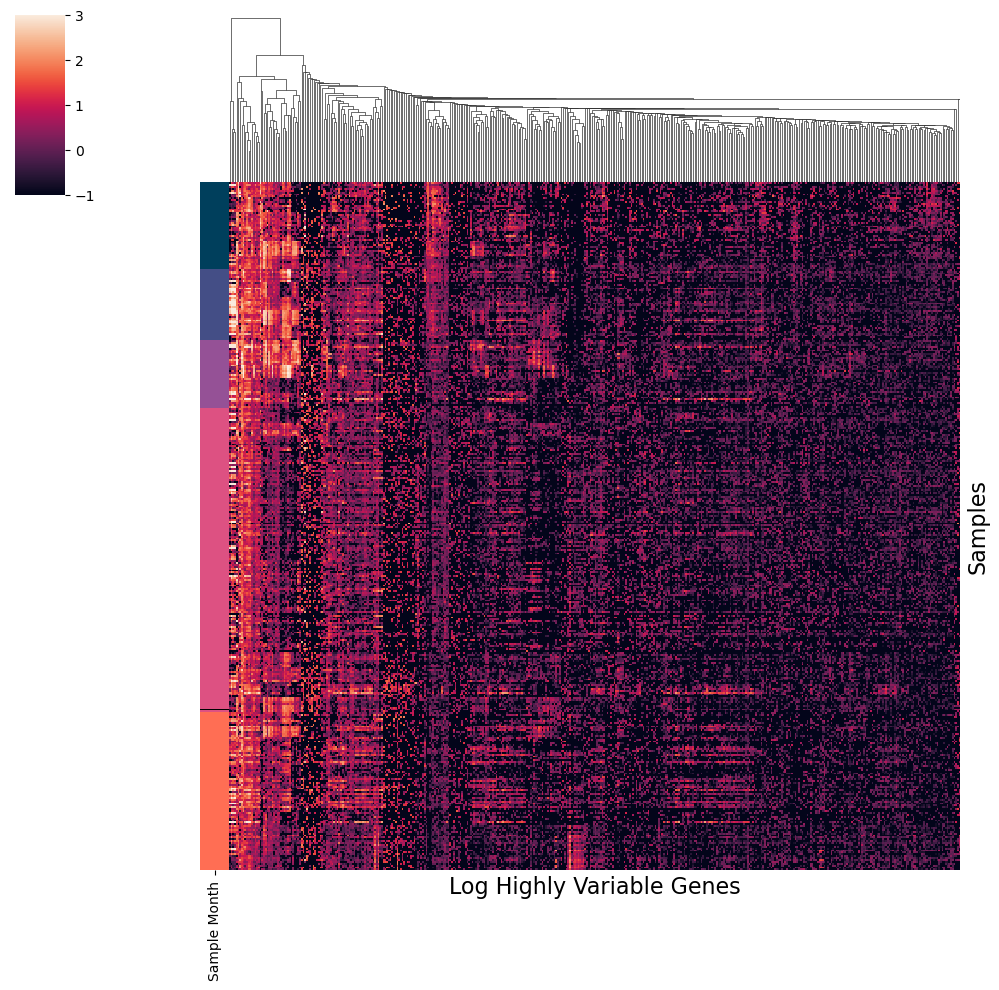

In [21]:
ax = sns.clustermap(
    log_normalized_transcriptome.reindex(
        index=trimmed_metadata.sort_values(by="daysincestart").index
    ),
    vmax=3,
    row_colors=row_colors_cloned,
    row_cluster=False,
    yticklabels=False,
    xticklabels=False,
)
plt.setp(
    ax.ax_heatmap.set_xlabel("Log Highly Variable Genes", fontsize=16),
)
plt.setp(ax.ax_heatmap.set_ylabel("Samples", fontsize=16))
# ax.savefig('/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Figs/transcriptome_highly_variable_genes_heatmap.pdf')

In [22]:
all_by_all_correlation = trimmed_transcriptome.T.corr(method="spearman")

all_by_all_correlation

,A2449446903_n01_LICRNA02_A01,A2449446903_n01_LICRNA02_A02,A2449446903_n01_LICRNA02_A03,A2449446903_n01_LICRNA02_A05,A2449446903_n01_LICRNA02_A06,A2449446903_n01_LICRNA02_A07,A2449446903_n01_LICRNA02_A08,A2449446903_n01_LICRNA02_A09,A2449446903_n01_LICRNA02_A10,A2449446903_n01_LICRNA02_A11,...,B250508004_n01_LICRNA03_H01,B250508004_n01_LICRNA03_H03,B250508004_n01_LICRNA03_H04,B250508004_n01_LICRNA03_H05,B250508004_n01_LICRNA03_H06,B250508004_n01_LICRNA03_H07,B250508004_n01_LICRNA03_H08,B250508004_n01_LICRNA03_H09,B250508004_n01_LICRNA03_H11,B250508004_n01_LICRNA03_H12
A2449446903_n01_LICRNA02_A01,1.000000,0.840287,0.835409,0.837822,0.827200,0.837830,0.842788,0.844998,0.825449,0.828342,...,0.832257,0.835985,0.841522,0.831279,0.840694,0.844623,0.834460,0.838119,0.831260,0.832436
A2449446903_n01_LICRNA02_A02,0.840287,1.000000,0.917698,0.904837,0.862162,0.909133,0.899472,0.902791,0.906417,0.899249,...,0.928403,0.923022,0.920181,0.922272,0.930171,0.934046,0.926291,0.930019,0.920081,0.926614
A2449446903_n01_LICRNA02_A03,0.835409,0.917698,1.000000,0.899622,0.851433,0.895139,0.885154,0.889323,0.891969,0.894207,...,0.909486,0.902730,0.900450,0.910965,0.916897,0.919319,0.913392,0.917031,0.908766,0.916416
A2449446903_n01_LICRNA02_A05,0.837822,0.904837,0.899622,1.000000,0.847208,0.892384,0.886345,0.880604,0.879119,0.887892,...,0.901382,0.894791,0.889429,0.900468,0.904722,0.914041,0.895585,0.908653,0.895033,0.900886
A2449446903_n01_LICRNA02_A06,0.827200,0.862162,0.851433,0.847208,1.000000,0.857319,0.839376,0.862424,0.846868,0.848777,...,0.849385,0.862302,0.856660,0.851443,0.852792,0.857477,0.852207,0.853007,0.841965,0.848383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,0.844623,0.934046,0.919319,0.914041,0.857477,0.906078,0.903671,0.898363,0.903651,0.906945,...,0.936932,0.917093,0.912242,0.925988,0.933111,1.000000,0.924529,0.936361,0.926210,0.931786
B250508004_n01_LICRNA03_H08,0.834460,0.926291,0.913392,0.895585,0.852207,0.898845,0.885222,0.892075,0.900916,0.896533,...,0.916463,0.911655,0.909771,0.917130,0.923212,0.924529,1.000000,0.919823,0.913575,0.922082
B250508004_n01_LICRNA03_H09,0.838119,0.930019,0.917031,0.908653,0.853007,0.904066,0.896375,0.899487,0.897034,0.902467,...,0.927803,0.913267,0.910272,0.921908,0.922721,0.936361,0.919823,1.000000,0.921022,0.927735
B250508004_n01_LICRNA03_H11,0.831260,0.920081,0.908766,0.895033,0.841965,0.888118,0.882783,0.881810,0.895038,0.889250,...,0.914141,0.900947,0.896827,0.924402,0.920992,0.926210,0.913575,0.921022,1.000000,0.927680


In [23]:
fig, ax = plt.subplots(figsize=(28, 20), dpi=1200)
fig.patch.set_facecolor("white")
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
ax = sns.heatmap(all_by_all_correlation, cmap="viridis")
# plt.xlabel("PCA 1 Transcriptome", fontsize=20)
# plt.ylabel("PCA 1 Bacterial Data", fontsize=20)
# sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
# ax.spines["bottom"].set_color("black")
# ax.spines["bottom"].set_linewidth(2)
# ax.spines["left"].set_color("black")
# ax.spines["left"].set_linewidth(2)
# ax.tick_params(axis="both", width=2)
# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(fontsize=0, rotation=90)
plt.yticks(fontsize=0)
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

# plt.ylim(0,10)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_58342/2511135526.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


(array([  0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,   7.5,   8.5,
          9.5,  10.5,  11.5,  12.5,  13.5,  14.5,  15.5,  16.5,  17.5,
         18.5,  19.5,  20.5,  21.5,  22.5,  23.5,  24.5,  25.5,  26.5,
         27.5,  28.5,  29.5,  30.5,  31.5,  32.5,  33.5,  34.5,  35.5,
         36.5,  37.5,  38.5,  39.5,  40.5,  41.5,  42.5,  43.5,  44.5,
         45.5,  46.5,  47.5,  48.5,  49.5,  50.5,  51.5,  52.5,  53.5,
         54.5,  55.5,  56.5,  57.5,  58.5,  59.5,  60.5,  61.5,  62.5,
         63.5,  64.5,  65.5,  66.5,  67.5,  68.5,  69.5,  70.5,  71.5,
         72.5,  73.5,  74.5,  75.5,  76.5,  77.5,  78.5,  79.5,  80.5,
         81.5,  82.5,  83.5,  84.5,  85.5,  86.5,  87.5,  88.5,  89.5,
         90.5,  91.5,  92.5,  93.5,  94.5,  95.5,  96.5,  97.5,  98.5,
         99.5, 100.5, 101.5, 102.5, 103.5, 104.5, 105.5, 106.5, 107.5,
        108.5, 109.5, 110.5, 111.5, 112.5, 113.5, 114.5, 115.5, 116.5,
        117.5, 118.5, 119.5, 120.5, 121.5, 122.5, 123.5, 124.5, 125.5,
      

In [24]:
all_by_all_correlation

,A2449446903_n01_LICRNA02_A01,A2449446903_n01_LICRNA02_A02,A2449446903_n01_LICRNA02_A03,A2449446903_n01_LICRNA02_A05,A2449446903_n01_LICRNA02_A06,A2449446903_n01_LICRNA02_A07,A2449446903_n01_LICRNA02_A08,A2449446903_n01_LICRNA02_A09,A2449446903_n01_LICRNA02_A10,A2449446903_n01_LICRNA02_A11,...,B250508004_n01_LICRNA03_H01,B250508004_n01_LICRNA03_H03,B250508004_n01_LICRNA03_H04,B250508004_n01_LICRNA03_H05,B250508004_n01_LICRNA03_H06,B250508004_n01_LICRNA03_H07,B250508004_n01_LICRNA03_H08,B250508004_n01_LICRNA03_H09,B250508004_n01_LICRNA03_H11,B250508004_n01_LICRNA03_H12
A2449446903_n01_LICRNA02_A01,1.000000,0.840287,0.835409,0.837822,0.827200,0.837830,0.842788,0.844998,0.825449,0.828342,...,0.832257,0.835985,0.841522,0.831279,0.840694,0.844623,0.834460,0.838119,0.831260,0.832436
A2449446903_n01_LICRNA02_A02,0.840287,1.000000,0.917698,0.904837,0.862162,0.909133,0.899472,0.902791,0.906417,0.899249,...,0.928403,0.923022,0.920181,0.922272,0.930171,0.934046,0.926291,0.930019,0.920081,0.926614
A2449446903_n01_LICRNA02_A03,0.835409,0.917698,1.000000,0.899622,0.851433,0.895139,0.885154,0.889323,0.891969,0.894207,...,0.909486,0.902730,0.900450,0.910965,0.916897,0.919319,0.913392,0.917031,0.908766,0.916416
A2449446903_n01_LICRNA02_A05,0.837822,0.904837,0.899622,1.000000,0.847208,0.892384,0.886345,0.880604,0.879119,0.887892,...,0.901382,0.894791,0.889429,0.900468,0.904722,0.914041,0.895585,0.908653,0.895033,0.900886
A2449446903_n01_LICRNA02_A06,0.827200,0.862162,0.851433,0.847208,1.000000,0.857319,0.839376,0.862424,0.846868,0.848777,...,0.849385,0.862302,0.856660,0.851443,0.852792,0.857477,0.852207,0.853007,0.841965,0.848383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,0.844623,0.934046,0.919319,0.914041,0.857477,0.906078,0.903671,0.898363,0.903651,0.906945,...,0.936932,0.917093,0.912242,0.925988,0.933111,1.000000,0.924529,0.936361,0.926210,0.931786
B250508004_n01_LICRNA03_H08,0.834460,0.926291,0.913392,0.895585,0.852207,0.898845,0.885222,0.892075,0.900916,0.896533,...,0.916463,0.911655,0.909771,0.917130,0.923212,0.924529,1.000000,0.919823,0.913575,0.922082
B250508004_n01_LICRNA03_H09,0.838119,0.930019,0.917031,0.908653,0.853007,0.904066,0.896375,0.899487,0.897034,0.902467,...,0.927803,0.913267,0.910272,0.921908,0.922721,0.936361,0.919823,1.000000,0.921022,0.927735
B250508004_n01_LICRNA03_H11,0.831260,0.920081,0.908766,0.895033,0.841965,0.888118,0.882783,0.881810,0.895038,0.889250,...,0.914141,0.900947,0.896827,0.924402,0.920992,0.926210,0.913575,0.921022,1.000000,0.927680


In [25]:
np.fill_diagonal(all_by_all_correlation.values, np.nan)
all_by_all_correlation

,A2449446903_n01_LICRNA02_A01,A2449446903_n01_LICRNA02_A02,A2449446903_n01_LICRNA02_A03,A2449446903_n01_LICRNA02_A05,A2449446903_n01_LICRNA02_A06,A2449446903_n01_LICRNA02_A07,A2449446903_n01_LICRNA02_A08,A2449446903_n01_LICRNA02_A09,A2449446903_n01_LICRNA02_A10,A2449446903_n01_LICRNA02_A11,...,B250508004_n01_LICRNA03_H01,B250508004_n01_LICRNA03_H03,B250508004_n01_LICRNA03_H04,B250508004_n01_LICRNA03_H05,B250508004_n01_LICRNA03_H06,B250508004_n01_LICRNA03_H07,B250508004_n01_LICRNA03_H08,B250508004_n01_LICRNA03_H09,B250508004_n01_LICRNA03_H11,B250508004_n01_LICRNA03_H12
A2449446903_n01_LICRNA02_A01,NaN,0.840287,0.835409,0.837822,0.827200,0.837830,0.842788,0.844998,0.825449,0.828342,...,0.832257,0.835985,0.841522,0.831279,0.840694,0.844623,0.834460,0.838119,0.831260,0.832436
A2449446903_n01_LICRNA02_A02,0.840287,NaN,0.917698,0.904837,0.862162,0.909133,0.899472,0.902791,0.906417,0.899249,...,0.928403,0.923022,0.920181,0.922272,0.930171,0.934046,0.926291,0.930019,0.920081,0.926614
A2449446903_n01_LICRNA02_A03,0.835409,0.917698,NaN,0.899622,0.851433,0.895139,0.885154,0.889323,0.891969,0.894207,...,0.909486,0.902730,0.900450,0.910965,0.916897,0.919319,0.913392,0.917031,0.908766,0.916416
A2449446903_n01_LICRNA02_A05,0.837822,0.904837,0.899622,NaN,0.847208,0.892384,0.886345,0.880604,0.879119,0.887892,...,0.901382,0.894791,0.889429,0.900468,0.904722,0.914041,0.895585,0.908653,0.895033,0.900886
A2449446903_n01_LICRNA02_A06,0.827200,0.862162,0.851433,0.847208,NaN,0.857319,0.839376,0.862424,0.846868,0.848777,...,0.849385,0.862302,0.856660,0.851443,0.852792,0.857477,0.852207,0.853007,0.841965,0.848383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B250508004_n01_LICRNA03_H07,0.844623,0.934046,0.919319,0.914041,0.857477,0.906078,0.903671,0.898363,0.903651,0.906945,...,0.936932,0.917093,0.912242,0.925988,0.933111,NaN,0.924529,0.936361,0.926210,0.931786
B250508004_n01_LICRNA03_H08,0.834460,0.926291,0.913392,0.895585,0.852207,0.898845,0.885222,0.892075,0.900916,0.896533,...,0.916463,0.911655,0.909771,0.917130,0.923212,0.924529,NaN,0.919823,0.913575,0.922082
B250508004_n01_LICRNA03_H09,0.838119,0.930019,0.917031,0.908653,0.853007,0.904066,0.896375,0.899487,0.897034,0.902467,...,0.927803,0.913267,0.910272,0.921908,0.922721,0.936361,0.919823,NaN,0.921022,0.927735
B250508004_n01_LICRNA03_H11,0.831260,0.920081,0.908766,0.895033,0.841965,0.888118,0.882783,0.881810,0.895038,0.889250,...,0.914141,0.900947,0.896827,0.924402,0.920992,0.926210,0.913575,0.921022,NaN,0.927680


In [48]:
quality_scores = all_by_all_correlation.sum(axis=1).sort_values(ascending=True)

In [44]:
bad_list = pd.read_csv(
    r"/Users/michael/Git/Outdoor_microbiome/Local_analysis/Analyze_transcriptome_with_temp_rain_microbiome/Misc_anlysis/bad_first_sample.csv",
    names=["Samples"],
)

In [45]:
metadata_indexed = metadata.reset_index()
metadata_indexed

,filename,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
0,A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00
1,A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00
2,A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00
3,A2450525897_n01_LICRNA01_D01,D01,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,49095.0,D,1,1359823.0,Long Term,November,0,2023-11-01 08:00:00
4,A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,B2449500127_n01_LICRNA04_D12,D12,LIC640,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,3683779.0,579120.0,D,12,7589546.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00
380,B2449500127_n01_LICRNA04_E12,E12,LIC641,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,1604732.0,248710.0,E,12,2868917.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00
381,B2449500127_n01_LICRNA04_F12,F12,LIC642,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,2279211.0,347737.0,F,12,3742922.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00
382,B2449500127_n01_LICRNA04_G12,G12,LIC643,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,3911417.0,548059.0,G,12,6883938.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00


In [47]:
bad_list["plate.pos"] = bad_list["Samples"].str.split(" ").str[-1]
bad_list["rnaprepplate"] = "LICRNA_0" + bad_list["Samples"].str.split(" ").str[1]
bad_list_filenames = bad_list.merge(
    metadata_indexed[["plate.pos", "rnaprepplate", "filename"]],
    how="left",
    on=["plate.pos", "rnaprepplate"],
)
bad_list_filenames

,Samples,plate.pos,rnaprepplate,filename
0,Plate 3 - A09,A09,LICRNA_03,B250508004_n01_LICRNA03_A09
1,Plate 2 - A01,A01,LICRNA_02,A2449446903_n01_LICRNA02_A01
2,Plate 2 - C10,C10,LICRNA_02,A2449446903_n01_LICRNA02_C10
3,Plate 2 - G10,G10,LICRNA_02,A2449446903_n01_LICRNA02_G10
4,Plate 1 - A02,A02,LICRNA_01,A2450525897_n01_LICRNA01_A02
5,Plate 1 - C02,C02,LICRNA_01,A2450525897_n01_LICRNA01_C02
6,Plate 1 - D01,D01,LICRNA_01,A2450525897_n01_LICRNA01_D01
7,Plate 1 - D02,D02,LICRNA_01,A2450525897_n01_LICRNA01_D02
8,Plate 1 - E04,E04,LICRNA_01,A2450525897_n01_LICRNA01_E04
9,Plate 1 - G01,G01,LICRNA_01,A2450525897_n01_LICRNA01_G01


In [65]:
bad_list_full = bad_list_filenames.merge(
    pd.DataFrame(quality_scores, columns=["Quality Score"]),
    left_on="filename",
    right_index=True,
    how="left",
)

In [66]:
bad_list_full

,Samples,plate.pos,rnaprepplate,filename,Quality Score
0,Plate 3 - A09,A09,LICRNA_03,B250508004_n01_LICRNA03_A09,297.473006
1,Plate 2 - A01,A01,LICRNA_02,A2449446903_n01_LICRNA02_A01,305.070003
2,Plate 2 - C10,C10,LICRNA_02,A2449446903_n01_LICRNA02_C10,312.623791
3,Plate 2 - G10,G10,LICRNA_02,A2449446903_n01_LICRNA02_G10,313.866677
4,Plate 1 - A02,A02,LICRNA_01,A2450525897_n01_LICRNA01_A02,311.999265
5,Plate 1 - C02,C02,LICRNA_01,A2450525897_n01_LICRNA01_C02,313.285081
6,Plate 1 - D01,D01,LICRNA_01,A2450525897_n01_LICRNA01_D01,314.785746
7,Plate 1 - D02,D02,LICRNA_01,A2450525897_n01_LICRNA01_D02,311.407871
8,Plate 1 - E04,E04,LICRNA_01,A2450525897_n01_LICRNA01_E04,317.268527
9,Plate 1 - G01,G01,LICRNA_01,A2450525897_n01_LICRNA01_G01,314.281477


In [67]:
bad_list_full["Rerun Priority for Sufficient Read Samples"] = bad_list_full[
    "Quality Score"
].rank()

In [69]:
bad_list_full
bad_list_full.to_csv(
    r"/Users/michael/Git/Outdoor_microbiome/Local_analysis/Analyze_transcriptome_with_temp_rain_microbiome/Misc_anlysis/sample_priority_list.csv"
)